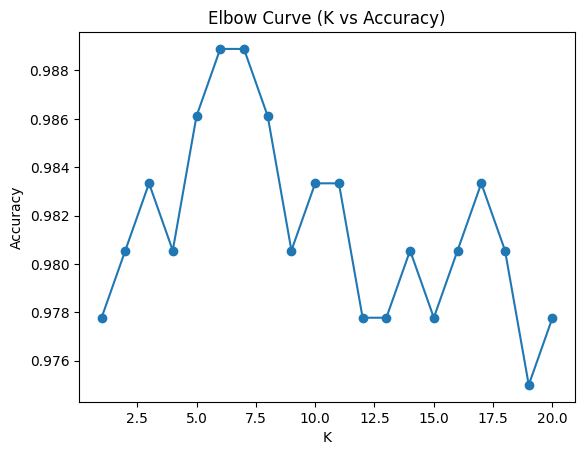

Best K: 6


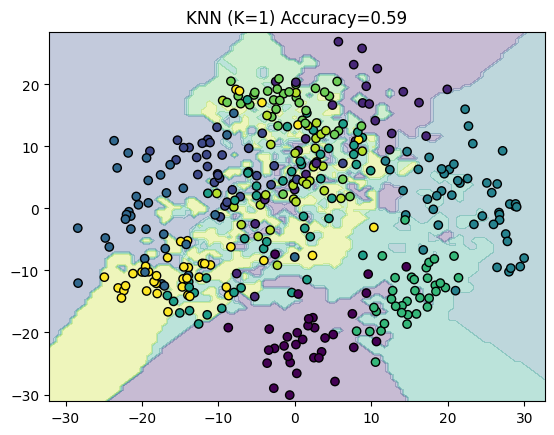

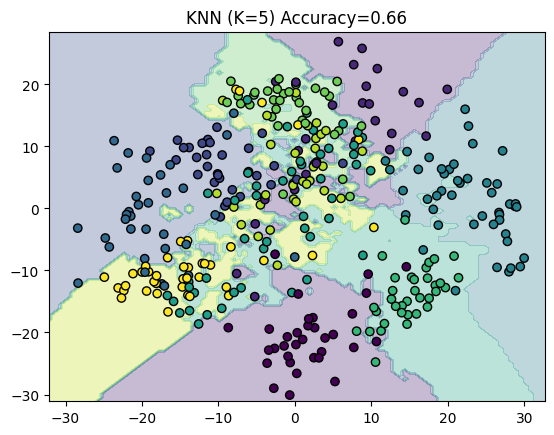

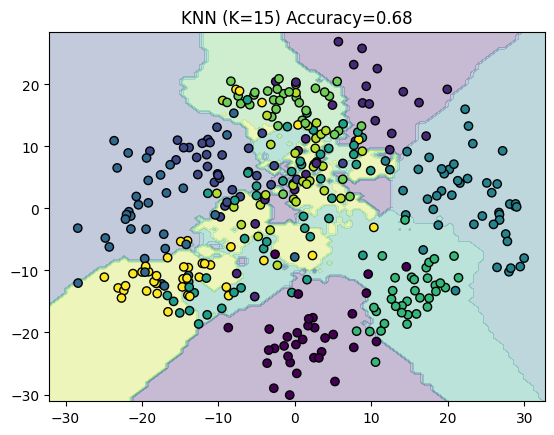


📊 FINAL MODEL COMPARISON
           Model  Accuracy  Precision    Recall  F1 Score
0            KNN  0.988889   0.990403  0.989931  0.990099
1     GaussianNB  0.847222   0.864984  0.847648  0.843735
2  MultinomialNB  1.000000   1.000000  1.000000  1.000000


In [32]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.feature_extraction.text import TfidfVectorizer

# ================================
# 2. DIGITS DATASET
# ================================
digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 3. ELBOW CURVE FOR KNN
# ================================
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.title("Elbow Curve (K vs Accuracy)")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

best_k = k_values[np.argmax(accuracies)]
print("Best K:", best_k)

# ================================
# 4. PCA FOR VISUALIZATION
# ================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# ================================
# 5. FUNCTION: DECISION BOUNDARY
# ================================
def plot_knn(k):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_p, y_train_p)
    acc = model.score(X_test_p, y_test_p)

    x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
    y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_test_p[:,0], X_test_p[:,1], c=y_test_p, edgecolor='k')
    plt.title(f"KNN (K={k}) Accuracy={acc:.2f}")
    plt.show()

plot_knn(1)
plot_knn(5)
plot_knn(15)

# ================================
# 6. GAUSSIAN NAIVE BAYES
# ================================
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_pred = gnb.predict(X_test)

# ================================
# 7. BEST KNN MODEL
# ================================
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
knn_pred = best_knn.predict(X_test)

# ================================
# 8. METRICS FUNCTION
# ================================
def metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro'),
        recall_score(y_true, y_pred, average='macro'),
        f1_score(y_true, y_pred, average='macro')
    ]

knn_metrics = metrics(y_test, knn_pred)
gnb_metrics = metrics(y_test, gnb_pred)

# ================================
# 9. 20 NEWSGROUPS (TEXT CLASSIFICATION)
# ================================
newsgroups = fetch_20newsgroups(subset='all', categories=['sci.space','rec.sport.baseball'])

vectorizer = TfidfVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(newsgroups.data)
y_text = newsgroups.target

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_text, y_text, test_size=0.2, random_state=42
)

mnb = MultinomialNB()
mnb.fit(X_train_t, y_train_t)
mnb_pred = mnb.predict(X_test_t)

mnb_metrics = metrics(y_test_t, mnb_pred)

# ================================
# 10. FINAL COMPARISON TABLE
# ================================
results = pd.DataFrame({
    "Model": ["KNN", "GaussianNB", "MultinomialNB"],
    "Accuracy": [knn_metrics[0], gnb_metrics[0], mnb_metrics[0]],
    "Precision": [knn_metrics[1], gnb_metrics[1], mnb_metrics[1]],
    "Recall": [knn_metrics[2], gnb_metrics[2], mnb_metrics[2]],
    "F1 Score": [knn_metrics[3], gnb_metrics[3], mnb_metrics[3]],
})

print("\n📊 FINAL MODEL COMPARISON")
print(results)

In [33]:
import pickle

# Save KNN model
with open("knn_model.pkl", "wb") as f:
    pickle.dump(best_knn, f)

# Save Gaussian NB model
with open("gnb_model.pkl", "wb") as f:
    pickle.dump(gnb, f)

# Save Multinomial NB model
with open("mnb_model.pkl", "wb") as f:
    pickle.dump(mnb, f)

print("✅ All models saved successfully!")

✅ All models saved successfully!


In [34]:
from google.colab import files

files.download("knn_model.pkl")
files.download("gnb_model.pkl")
files.download("mnb_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>